# Spin-up Quick Check Notebook
This notebook is organized for spin-up diagnostics on monthly model output.

## Task 1: Domain map animation of a selected biological variable
- Input file: `dws_500m.3d.201501.nc`
- Goal: animate a selected variable over time on the model map
- Output: an animated GIF (optional) and inline animation preview

## Task 2: Aggregated time series of a selected biological variable for the whole domain
- Cell 2 (Task 2): build and plot the domain-mean trend at a selected layer (4d) or 3d variable
- Input file: `dws_500m.3d.201501.nc`
- Goal: visualize time series of spatially averaged values over the whole domain also for a specific vertical level;
- Output: a time-series line plot

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from matplotlib.animation import FuncAnimation
from pathlib import Path
from IPython.display import HTML

In [13]:
# ------------------------------ User settings ------------------------------
NETCDF_PATH = Path('/export/lv9/user/qzhan/archived_output/hydro_bio/spinup/2015_run_01/dws_500m.3d.201501.nc')
# OUTPUT_GIF = Path('/export/lv9/user/qzhan/archived_output/hydro_bio/spinup/figures/dws500m_domain_bio.gif')

PLOTVAR = 'N1p'
LAYER_INDEX = 10  # top=11, bottom=1
TIME_STEP = 1
VMIN = None
VMAX = None
CMAP = 'viridis'


def _find_time_dim(da: xr.DataArray) -> str:
    for d in da.dims:
        if 'time' in d.lower():
            return d
    raise ValueError(f'No time-like dimension found in {da.dims}')


def _find_vertical_dim(da: xr.DataArray, time_dim: str) -> str:
    candidates = ('level', 'z', 'sigma', 'layer', 'lev', 'depth', 'nmesh2_layer_3d')
    for d in da.dims:
        if d == time_dim:
            continue
        if any(k in d.lower() for k in candidates):
            return d
    if len(da.dims) >= 3:
        return da.dims[1]
    raise ValueError(f'No vertical-like dimension found in {da.dims}')


def _find_xy_dims(da: xr.DataArray, time_dim: str, z_dim: str) -> tuple[str, str]:
    remain = [d for d in da.dims if d not in (time_dim, z_dim)]
    if len(remain) != 2:
        raise ValueError(f'Expected 2 horizontal dims after removing time/z, got {remain} from {da.dims}')
    return remain[0], remain[1]


def _pick_coord_name(ds: xr.Dataset, candidates: tuple[str, ...]) -> str | None:
    for name in candidates:
        if name in ds.variables:
            return name
    return None


def _to_float(values) -> np.ndarray:
    if np.ma.isMaskedArray(values):
        values = np.ma.filled(values, np.nan)
    return np.asarray(values, dtype=float)


def _to_yx(arr_da: xr.DataArray, y_dim: str, x_dim: str) -> np.ndarray:
    if y_dim in arr_da.dims and x_dim in arr_da.dims:
        return _to_float(arr_da.transpose(y_dim, x_dim).values)
    return _to_float(arr_da.values)


# ------------------------------ Load and prepare data ------------------------------
ds = xr.open_dataset(NETCDF_PATH, decode_times=True)

if PLOTVAR not in ds.variables:
    raise KeyError(f"Variable '{PLOTVAR}' not found. Available: {sorted(ds.data_vars)}")

da = ds[PLOTVAR]
plot_units = da.attrs.get('units', '')
plot_units_label = f" [{plot_units}]" if plot_units else ''
time_dim = _find_time_dim(da)
z_dim = _find_vertical_dim(da, time_dim)
y_dim, x_dim = _find_xy_dims(da, time_dim, z_dim)

if LAYER_INDEX >= da.sizes[z_dim] or LAYER_INDEX < -da.sizes[z_dim]:
    raise IndexError(f"LAYER_INDEX={LAYER_INDEX} out of bounds for '{z_dim}' size {da.sizes[z_dim]}")

field = da.isel({z_dim: LAYER_INDEX})
times = field[time_dim]
frame_indices = np.arange(0, field.sizes[time_dim], TIME_STEP)
if len(frame_indices) == 0:
    raise ValueError('No frames selected. Check TIME_STEP and time length.')

ny = field.sizes[y_dim]
nx = field.sizes[x_dim]

# Try geographic coordinates first.
lon_name = _pick_coord_name(ds, ('lonc', 'lon', 'longitude'))
lat_name = _pick_coord_name(ds, ('latc', 'lat', 'latitude'))

use_geo = False
if lon_name is not None and lat_name is not None:
    lon_da = ds[lon_name]
    lat_da = ds[lat_name]

    if y_dim in lon_da.dims and x_dim in lon_da.dims and y_dim in lat_da.dims and x_dim in lat_da.dims:
        x_geo = _to_yx(lon_da, y_dim, x_dim)
        y_geo = _to_yx(lat_da, y_dim, x_dim)

        # pcolormesh requires finite X and Y everywhere.
        if x_geo.shape == (ny, nx) and y_geo.shape == (ny, nx):
            if np.isfinite(x_geo).all() and np.isfinite(y_geo).all():
                x_plot, y_plot = x_geo, y_geo
                use_geo = True

# Fallback to index space when lon/lat has NaN or masked cells.
if not use_geo:
    x_plot, y_plot = np.meshgrid(np.arange(nx, dtype=float), np.arange(ny, dtype=float))

all_values = _to_float(field.values)
vmin = float(np.nanmin(all_values)) if VMIN is None else float(VMIN)
vmax = float(np.nanmax(all_values)) if VMAX is None else float(VMAX)
if vmax <= vmin:
    vmax = vmin + 1e-12

# ------------------------------ Animation setup -----------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
plt.close(fig)

norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label(f'{PLOTVAR}{plot_units_label}')

def update(frame_number: int):
    frame_idx = int(frame_indices[frame_number])
    frame2d = _to_float(field.isel({time_dim: frame_idx}).transpose(y_dim, x_dim).values)

    ax.clear()
    mesh = ax.pcolormesh(
        x_plot,
        y_plot,
        np.ma.masked_invalid(frame2d),
        shading='auto',
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    tval = np.asarray(times.isel({time_dim: frame_idx}).values)
    ax.set_title(f'{PLOTVAR}{plot_units_label} | layer {LAYER_INDEX} | {tval}')
    ax.set_xlabel('Longitude' if use_geo else x_dim)
    ax.set_ylabel('Latitude' if use_geo else y_dim)
    ax.grid(True, alpha=0.2)
    return (mesh,)

ani = FuncAnimation(fig, update, frames=len(frame_indices), interval=180, blit=False, repeat=False)
html_anim = HTML(ani.to_jshtml())

# Uncomment if you want GIF output
# OUTPUT_GIF.parent.mkdir(parents=True, exist_ok=True)
# ani.save(OUTPUT_GIF, writer=PillowWriter(fps=6))
# print(f'Saved animation to: {OUTPUT_GIF}')

html_anim

In [ ]:
# ------------------------------ Task 1 -----------------------------------
# Goal: animate a selected 3D variable without a vertical level over time on the model map.

PLOTVAR = 'H1c'            # e.g. Aerobic benthic bacteria without vertical levels (H1c)
TIME_STEP = 1
VMIN = None
VMAX = None
CMAP = 'viridis'


def _find_time_dim(da: xr.DataArray) -> str:
    for d in da.dims:
        if 'time' in d.lower():
            return d
    raise ValueError(f'No time-like dimension found in {da.dims}')


def _find_xy_dims(da: xr.DataArray, time_dim: str) -> tuple[str, str]:
    remain = [d for d in da.dims if d != time_dim]
    if len(remain) != 2:
        raise ValueError(f'Expected 2 horizontal dims after removing time, got {remain} from {da.dims}')
    return remain[0], remain[1]


def _pick_coord_name(ds: xr.Dataset, candidates: tuple[str, ...]) -> str | None:
    for name in candidates:
        if name in ds.variables:
            return name
    return None


def _to_float(values) -> np.ndarray:
    if np.ma.isMaskedArray(values):
        values = np.ma.filled(values, np.nan)
    return np.asarray(values, dtype=float)


def _to_yx(arr_da: xr.DataArray, y_dim: str, x_dim: str) -> np.ndarray:
    if y_dim in arr_da.dims and x_dim in arr_da.dims:
        return _to_float(arr_da.transpose(y_dim, x_dim).values)
    return _to_float(arr_da.values)


# ------------------------------ Load and prepare data ------------------------------
ds = xr.open_dataset(NETCDF_PATH, decode_times=True)

if PLOTVAR not in ds.variables:
    raise KeyError(f"Variable '{PLOTVAR}' not found. Available: {sorted(ds.data_vars)}")

da = ds[PLOTVAR].squeeze(drop=True)
plot_units = da.attrs.get('units', '')
plot_units_label = f" [{plot_units}]" if plot_units else ''
time_dim = _find_time_dim(da)
y_dim, x_dim = _find_xy_dims(da, time_dim)

ny = da.sizes[y_dim]
nx = da.sizes[x_dim]
frame_indices = np.arange(0, da.sizes[time_dim], TIME_STEP)
if len(frame_indices) == 0:
    raise ValueError('No frames selected. Check TIME_STEP and time length.')

# Try geographic coordinates first.
lon_name = _pick_coord_name(ds, ('lonc', 'lon', 'longitude'))
lat_name = _pick_coord_name(ds, ('latc', 'lat', 'latitude'))

use_geo = False
if lon_name is not None and lat_name is not None:
    lon_da = ds[lon_name]
    lat_da = ds[lat_name]

    if y_dim in lon_da.dims and x_dim in lon_da.dims and y_dim in lat_da.dims and x_dim in lat_da.dims:
        x_geo = _to_yx(lon_da, y_dim, x_dim)
        y_geo = _to_yx(lat_da, y_dim, x_dim)

        # pcolormesh requires finite X and Y everywhere.
        if x_geo.shape == (ny, nx) and y_geo.shape == (ny, nx):
            if np.isfinite(x_geo).all() and np.isfinite(y_geo).all():
                x_plot, y_plot = x_geo, y_geo
                use_geo = True

# Fallback to index space when lon/lat has NaN or masked cells.
if not use_geo:
    x_plot, y_plot = np.meshgrid(np.arange(nx, dtype=float), np.arange(ny, dtype=float))

all_values = _to_float(da.values)
vmin = float(np.nanmin(all_values)) if VMIN is None else float(VMIN)
vmax = float(np.nanmax(all_values)) if VMAX is None else float(VMAX)
if vmax <= vmin:
    vmax = vmin + 1e-12

# ------------------------------ Animation setup -----------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
plt.close(fig)

norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label(f'{PLOTVAR}{plot_units_label}')

def update(frame_number: int):
    frame_idx = int(frame_indices[frame_number])
    frame2d = _to_float(da.isel({time_dim: frame_idx}).transpose(y_dim, x_dim).values)

    ax.clear()
    mesh = ax.pcolormesh(
        x_plot,
        y_plot,
        np.ma.masked_invalid(frame2d),
        shading='auto',
        cmap=CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    tval = np.asarray(da[time_dim].isel({time_dim: frame_idx}).values)
    ax.set_title(f'{PLOTVAR}{plot_units_label} | {tval}')
    ax.set_xlabel('Longitude' if use_geo else x_dim)
    ax.set_ylabel('Latitude' if use_geo else y_dim)
    ax.grid(True, alpha=0.2)
    return (mesh,)

ani = FuncAnimation(fig, update, frames=len(frame_indices), interval=180, blit=False, repeat=False)
html_anim = HTML(ani.to_jshtml())

# Uncomment if you want GIF output
# OUTPUT_GIF.parent.mkdir(parents=True, exist_ok=True)
# ani.save(OUTPUT_GIF, writer=PillowWriter(fps=6))
# print(f'Saved animation to: {OUTPUT_GIF}')

html_anim

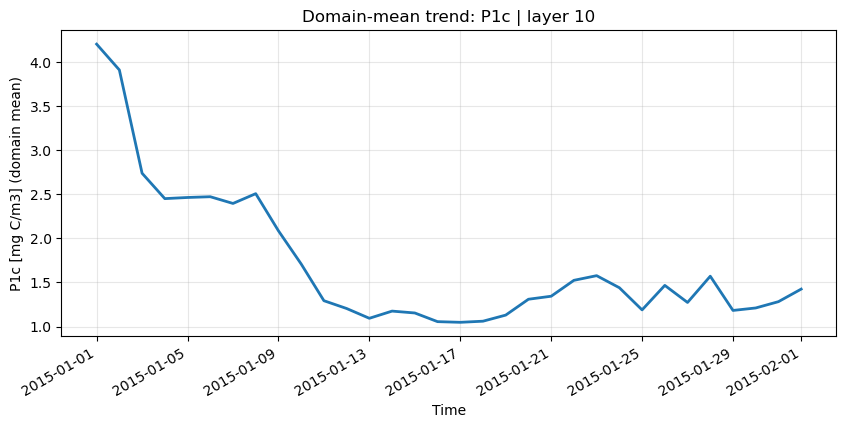

Plotted P1c trend using layer 10 and domain mean over dims ['yc', 'xc'].
Valid points: 32 / 32
Min/Max: 1.04783 / 4.20632


In [12]:
# ------------------------------ Task 2 -----------------------------------
# Trend of a selected biological variable over the month,
# using domain-average values at a selected layer.

TREND_VAR = 'P1c'            # e.g. N1p, N3n, O2o, Chl
TREND_LAYER_INDEX = 10       # Python indexing: 10=topmost, 1=bottom-most in many GETM outputs
USE_DAILY_MEAN = False       # True to smooth high-frequency output to daily means
ROLLING_WINDOW = None        # e.g. 3 for a 3-step rolling mean, or None to disable
SAVE_FIG = None              # e.g. Path('trend_N1p_layer_top.png') or None

# Reuse an already-open dataset from Task 1 if available; otherwise open it.
try:
    ds
except NameError:
    ds = xr.open_dataset(NETCDF_PATH, decode_times=True)

if TREND_VAR not in ds.variables:
    raise KeyError(f"Variable '{TREND_VAR}' not found. Available: {sorted(ds.data_vars)}")

trend_da = ds[TREND_VAR]
trend_units = trend_da.attrs.get('units', '')
trend_units_label = f" [{trend_units}]" if trend_units else ''

# Detect dimensions robustly for files using (time, level, yc, xc) or similar.
trend_time_dim = next((d for d in trend_da.dims if 'time' in d.lower()), None)
if trend_time_dim is None:
    raise ValueError(f'No time dimension found in {trend_da.dims}')

z_candidates = ('level', 'z', 'sigma', 'layer', 'lev', 'depth', 'nmesh2_layer_3d')
trend_z_dim = next((d for d in trend_da.dims if d != trend_time_dim and any(k in d.lower() for k in z_candidates)), None)
if trend_z_dim is None:
    raise ValueError(f'No vertical dimension found in {trend_da.dims}')

trend_xy_dims = [d for d in trend_da.dims if d not in (trend_time_dim, trend_z_dim)]
if len(trend_xy_dims) != 2:
    raise ValueError(f'Expected 2 horizontal dims, got {trend_xy_dims} from {trend_da.dims}')

if TREND_LAYER_INDEX >= trend_da.sizes[trend_z_dim] or TREND_LAYER_INDEX < -trend_da.sizes[trend_z_dim]:
    raise IndexError(
        f"TREND_LAYER_INDEX={TREND_LAYER_INDEX} out of bounds for '{trend_z_dim}' size {trend_da.sizes[trend_z_dim]}"
    )

# Domain mean over spatial dims for each time step.
trend_layer = trend_da.isel({trend_z_dim: TREND_LAYER_INDEX})
trend_series = trend_layer.mean(dim=trend_xy_dims, skipna=True)

# Optional smoothing to daily means.
if USE_DAILY_MEAN:
    trend_series_plot = trend_series.resample({trend_time_dim: '1D'}).mean(skipna=True)
else:
    trend_series_plot = trend_series

# Optional rolling mean on the selected time series.
if ROLLING_WINDOW is not None:
    if ROLLING_WINDOW < 1:
        raise ValueError('ROLLING_WINDOW must be >= 1 or None')
    trend_series_plot = trend_series_plot.rolling({trend_time_dim: ROLLING_WINDOW}, center=True).mean()

trend_times = trend_series_plot[trend_time_dim].values
trend_values = trend_series_plot.values

fig2, ax2 = plt.subplots(figsize=(10, 4.5))
ax2.plot(trend_times, trend_values, lw=2)
ax2.set_title(f"Domain-mean trend: {TREND_VAR} | layer {TREND_LAYER_INDEX}")
ax2.set_xlabel('Time')
ax2.set_ylabel(f'{TREND_VAR}{trend_units_label} (domain mean)')
ax2.grid(True, alpha=0.3)
fig2.autofmt_xdate()

#if SAVE_FIG is not None:
#    save_path = Path(SAVE_FIG)
#    save_path.parent.mkdir(parents=True, exist_ok=True)
#    fig2.savefig(save_path, dpi=200, bbox_inches='tight')
#    print(f'Saved figure to: {save_path}')

plt.show()

print(f"Plotted {TREND_VAR} trend using layer {TREND_LAYER_INDEX} and domain mean over dims {trend_xy_dims}.")
print(f"Valid points: {np.isfinite(trend_values).sum()} / {trend_values.size}")
print(f"Min/Max: {np.nanmin(trend_values):.6g} / {np.nanmax(trend_values):.6g}")

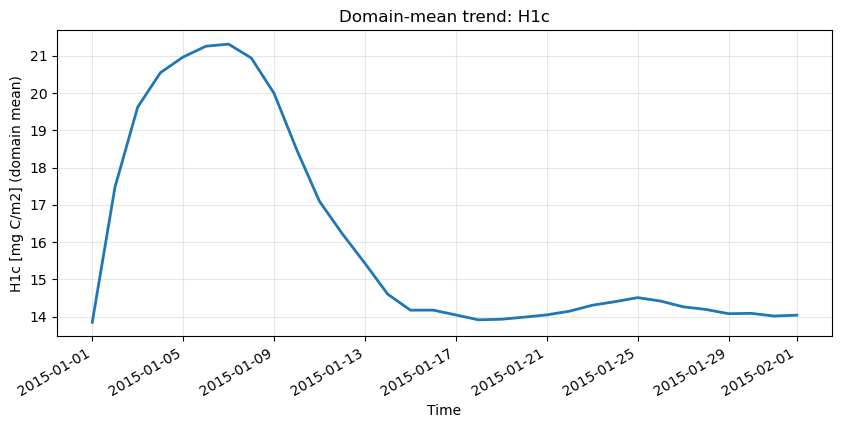

Plotted H1c domain-mean trend over dims ['yc', 'xc'].
Valid points: 32 / 32
Min/Max: 13.8503 / 21.3109


In [11]:
# ------------------------------ Task 2 -----------------------------------
# Trend of a selected biological variable over the month,
# using domain-average values for variables without a vertical level.

TREND_VAR = 'H1c'            # e.g. Aerobic benthic bacteria (H1c), Anaerobic benthic bacteria (H2c)
USE_DAILY_MEAN = False       # True to smooth high-frequency output to daily means
ROLLING_WINDOW = None        # e.g. 3 for a 3-step rolling mean, or None to disable
SAVE_FIG = None              # e.g. Path('trend_H1c_domain_mean.png') or None

# Reuse an already-open dataset from Task 1 if available; otherwise open it.
try:
    ds
except NameError:
    ds = xr.open_dataset(NETCDF_PATH, decode_times=True)

if TREND_VAR not in ds.variables:
    raise KeyError(f"Variable '{TREND_VAR}' not found. Available: {sorted(ds.data_vars)}")

trend_da = ds[TREND_VAR].squeeze(drop=True)
trend_units = trend_da.attrs.get('units', '')
trend_units_label = f" [{trend_units}]" if trend_units else ''

# Detect the time dimension and assume the remaining dimensions are horizontal.
trend_time_dim = next((d for d in trend_da.dims if 'time' in d.lower()), None)
if trend_time_dim is None:
    raise ValueError(f'No time dimension found in {trend_da.dims}')

trend_spatial_dims = [d for d in trend_da.dims if d != trend_time_dim]
if len(trend_spatial_dims) != 2:
    raise ValueError(
        f'Expected a time dimension plus 2 horizontal dims for a no-layer variable, '
        f'got {trend_da.dims}'
    )

# Domain mean over the two horizontal dimensions for each time step.
trend_series = trend_da.mean(dim=trend_spatial_dims, skipna=True)

# Optional smoothing to daily means.
if USE_DAILY_MEAN:
    trend_series_plot = trend_series.resample({trend_time_dim: '1D'}).mean(skipna=True)
else:
    trend_series_plot = trend_series

# Optional rolling mean on the selected time series.
if ROLLING_WINDOW is not None:
    if ROLLING_WINDOW < 1:
        raise ValueError('ROLLING_WINDOW must be >= 1 or None')
    trend_series_plot = trend_series_plot.rolling({trend_time_dim: ROLLING_WINDOW}, center=True).mean()

trend_times = trend_series_plot[trend_time_dim].values
trend_values = trend_series_plot.values

fig2, ax2 = plt.subplots(figsize=(10, 4.5))
ax2.plot(trend_times, trend_values, lw=2)
ax2.set_title(f"Domain-mean trend: {TREND_VAR}")
ax2.set_xlabel('Time')
ax2.set_ylabel(f'{TREND_VAR}{trend_units_label} (domain mean)')
ax2.grid(True, alpha=0.3)
fig2.autofmt_xdate()

#if SAVE_FIG is not None:
#    save_path = Path(SAVE_FIG)
#    save_path.parent.mkdir(parents=True, exist_ok=True)
#    fig2.savefig(save_path, dpi=200, bbox_inches='tight')
#    print(f'Saved figure to: {save_path}')

plt.show()

print(f"Plotted {TREND_VAR} domain-mean trend over dims {trend_spatial_dims}.")
print(f"Valid points: {np.isfinite(trend_values).sum()} / {trend_values.size}")
print(f"Min/Max: {np.nanmin(trend_values):.6g} / {np.nanmax(trend_values):.6g}")